# 1. Project Overview

# MCP-Powered Multi-Agent Air Quality Reasoning System — Data Preparation

This notebook prepares the **Air Pollution Image Dataset (India & Nepal)** as part of a broader  
**MCP-powered Multi-Agent Air Quality Reasoning System**.

## Dataset Overview
The dataset contains:
- Street-level images captured across urban and semi-urban locations in India and Nepal
- Corresponding sensor-based air quality measurements (PM2.5, PM10, NO₂, SO₂, CO, O₃)
- Discrete Air Quality Index (AQI) categories representing pollution severity

Each image reflects real-world atmospheric conditions such as haze, smog density, and visibility loss that correlate with pollution levels.

The dataset is organized around six AQI categories:
- Good  
- Moderate  
- Unhealthy for Sensitive Groups  
- Unhealthy  
- Very Unhealthy  
- Severe  

These classes represent increasing health risk and environmental degradation.

## System Objective
This project is part of a **Multi-Agent Reasoning System** designed to:
- Perceive air quality from heterogeneous data sources
- Reason about pollution severity and health risk
- Support decision-making for environmental monitoring and public awareness

The agents in the system include:
- **Perception Agent** — extracts visual features from images using CNNs  
- **Sensor Agent** — analyzes tabular pollutant measurements  
- **Reasoning Agent** — combines perceptual and numerical evidence to infer AQI severity  
- **Explanation Agent** — provides human-interpretable justification of predictions  

This notebook focuses on the **Perception Agent’s data pipeline** — preparing image data for robust and unbiased learning.

## Goals of This Notebook
- Load and validate the air pollution image dataset
- Build consistent image paths from metadata
- Clean and verify image integrity
- Split data into training and validation sets
- Apply appropriate preprocessing and augmentation
- Visualize dataset characteristics and potential biases
- Prepare PyTorch DataLoaders for downstream agents

## Final Goal
The final objective is to enable the system to **perceive and reason about air quality visually**, complementing sensor-based measurements and supporting explainable, multi-modal environmental intelligence.


# 2. Imports & Setup

In [1]:
import os
import torch
import random
import kagglehub
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# 3. Download & Load Dataset

In [3]:
path = kagglehub.dataset_download("adarshrouniyar/air-pollution-image-dataset-from-india-and-nepal")
ROOT = os.path.join(path, "Air Pollution Image Dataset/Air Pollution Image Dataset/Combined_Dataset")
IMAGE_ROOT = os.path.join(ROOT, "IND_and_NEP")
df = pd.read_csv(os.path.join(ROOT, "IND_and_Nep_AQI_Dataset.csv"))
df.head()

Using Colab cache for faster access to the 'air-pollution-image-dataset-from-india-and-nepal' dataset.


,Location,Filename,Year,Month,Day,Hour,AQI,PM2.5,PM10,O3,CO,SO2,NO2,AQI_Class
0,"Biratnagar, Nepal",BRI_Un_2023-02-02- 12.00-9.jpg,2023,2,2,12:00,158,70.08,100.82,58.89,0.49,4.4,1.04,d_Unhealthy
1,"Biratnagar, Nepal",BRI_Un_2023-02-02- 12.00-8.jpg,2023,2,2,12:00,158,70.08,100.82,58.89,0.49,4.4,1.04,d_Unhealthy
2,"Biratnagar, Nepal",BRI_Un_2023-02-02- 12.00-7.jpg,2023,2,2,12:00,158,70.08,100.82,58.89,0.49,4.4,1.04,d_Unhealthy
3,"Biratnagar, Nepal",BRI_Un_2023-02-02- 12.00-6.jpg,2023,2,2,12:00,158,70.08,100.82,58.89,0.49,4.4,1.04,d_Unhealthy
4,"Biratnagar, Nepal",BRI_Un_2023-02-02- 12.00-5.jpg,2023,2,2,12:00,158,70.08,100.82,58.89,0.49,4.4,1.04,d_Unhealthy


# 4. Dataset Inspection

In [4]:
df.shape, df.columns

((12240, 14),
 Index(['Location', 'Filename', 'Year', 'Month', 'Day', 'Hour', 'AQI', 'PM2.5',
        'PM10', 'O3', 'CO', 'SO2', 'NO2', 'AQI_Class'],
       dtype='object'))

In [5]:
df["AQI_Class"].value_counts()

,count
AQI_Class,
c_Unhealthy_for_Sensitive_Groups,2863
d_Unhealthy,2622
e_Very_Unhealthy,2194
b_Moderate,1573
a_Good,1541
f_Severe,1447


# 5. Build Image Paths & Labels

In [6]:
df["image_path"] = IMAGE_ROOT + "/" + df["AQI_Class"] + "/" + df["Filename"]

class_map = {
    "a_Good": 0,
    "b_Moderate": 1,
    "c_Unhealthy_for_Sensitive_Groups": 2,
    "d_Unhealthy": 3,
    "e_Very_Unhealthy": 4,
    "f_Severe": 5
}
df["label"] = df["AQI_Class"].map(class_map)

# 6. Validate Image Paths

In [7]:
df["image_path"].apply(os.path.exists).value_counts()

,count
image_path,
True,12240


In [8]:
from tqdm import tqdm

def filter_valid_images(df):
    valid_indices = []
    for i, p in tqdm(enumerate(df["image_path"]), total=len(df)):
        try:
            with Image.open(p) as img:
                img = img.convert("RGB")
                img.resize((10,10))
            valid_indices.append(i)
        except:
            pass
    return df.iloc[valid_indices].reset_index(drop=True)
df = filter_valid_images(df)
print("Remaining images:", len(df))

100%|██████████| 12240/12240 [00:17<00:00, 698.67it/s]

Remaining images: 12240


# 7. Train / Validation Split

In [9]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

# 8. Data Augmentation & Preprocessing

In [10]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 9. Custom Dataset Class

In [11]:
class AQIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.paths = df["image_path"].values
        self.labels = df["label"].values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# 10. Create DataLoaders

In [12]:
train_dataset = AQIDataset(train_df, transform=train_transforms)
val_dataset = AQIDataset(val_df, transform=val_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
imgs, labels = next(iter(train_loader))
imgs.shape, labels.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

# 11. Class Distribution

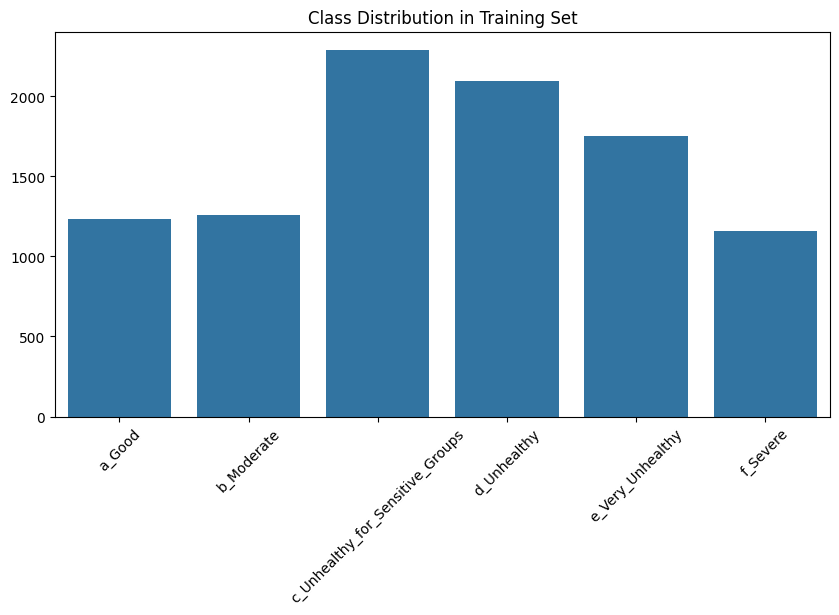

In [13]:
class_counts = train_df["label"].value_counts().sort_index()
inv_class_map = {v: k for k, v in class_map.items()}
class_names = [inv_class_map[i] for i in class_counts.index]
plt.figure(figsize=(10,5))
sns.barplot(x=class_names, y=class_counts.values)
plt.xticks(rotation=45)
plt.title("Class Distribution in Training Set")
plt.show()

# 12. Visualize Sample Images

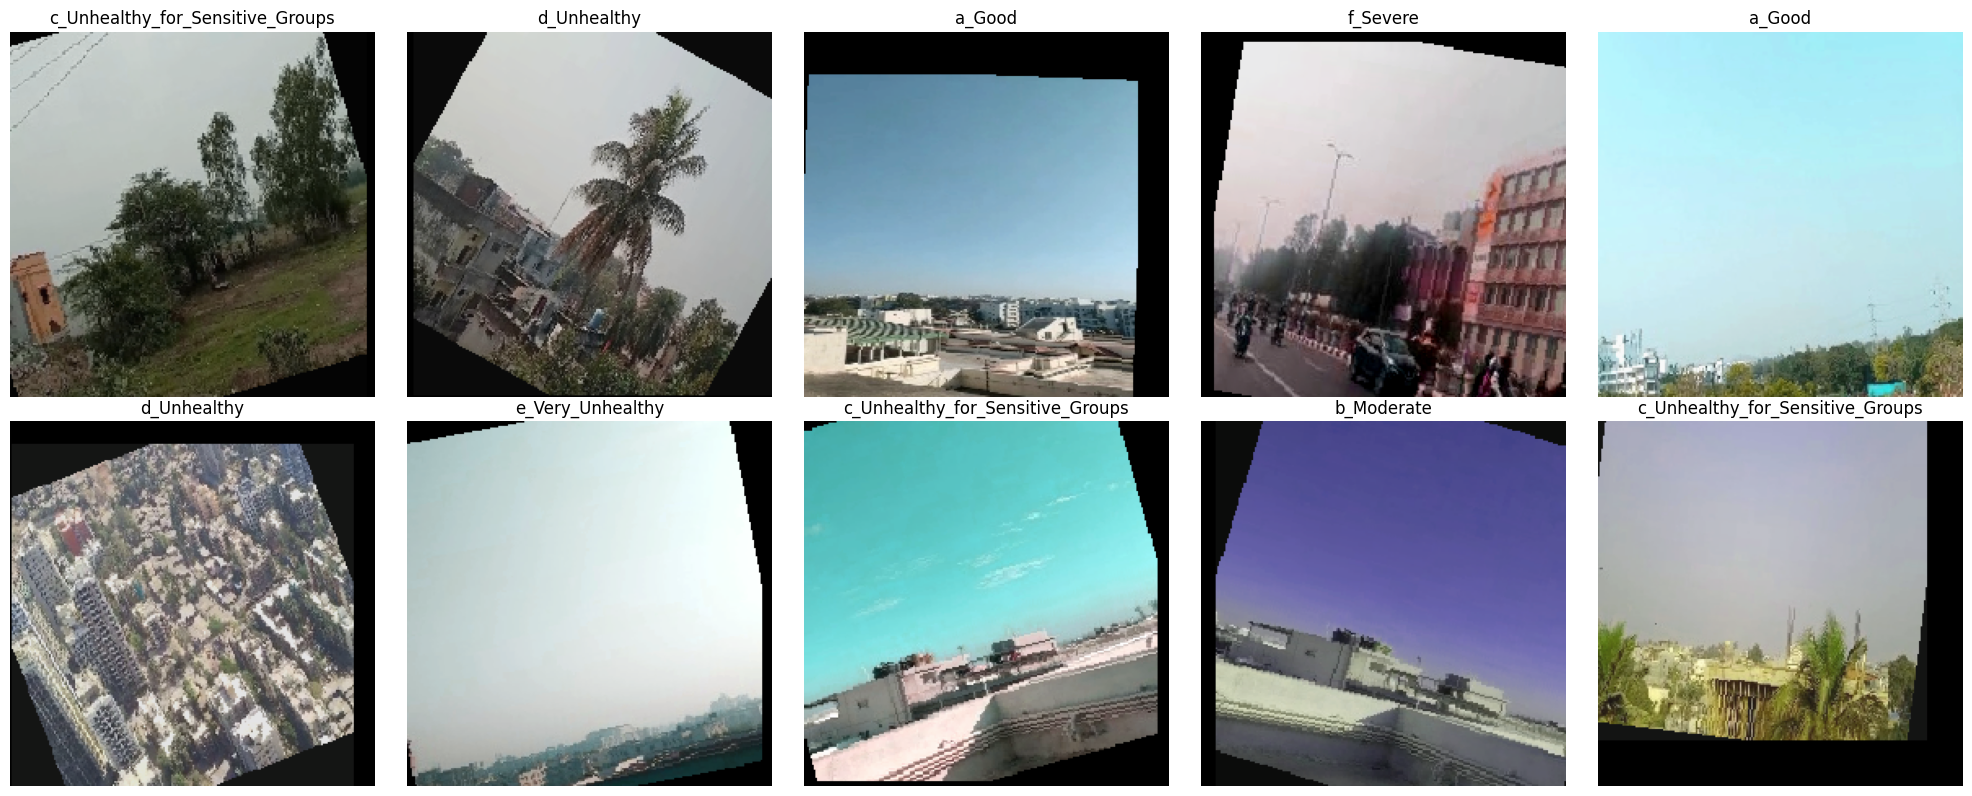

In [14]:
def show_images(dataset, num_images=10, rows=2):
    cols = int(np.ceil(num_images / rows))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()
    indices = np.random.randint(0, len(dataset), size=num_images)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        img = img.permute(1, 2, 0).numpy()
        img = img * std + mean
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(inv_class_map[label])
        axes[i].axis("off")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()
show_images(train_dataset)

# 13. Image Size Distribution

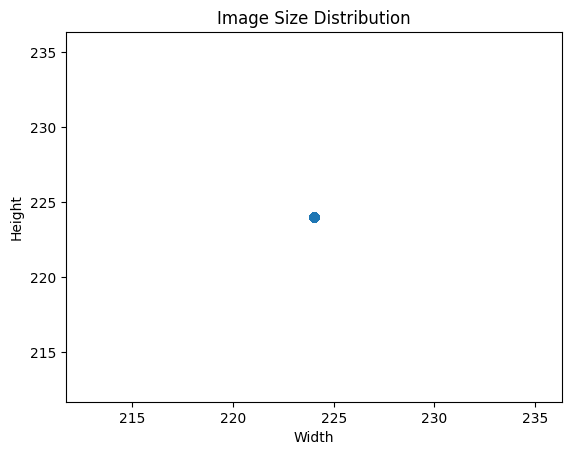

In [15]:
image_shapes = []
for p in train_df["image_path"]:
    with Image.open(p) as img:
        image_shapes.append(img.size)
image_shapes = np.array(image_shapes)
plt.scatter(image_shapes[:,0], image_shapes[:,1], alpha=0.5)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")
plt.show()

#14. Pixel Intensity Distribution

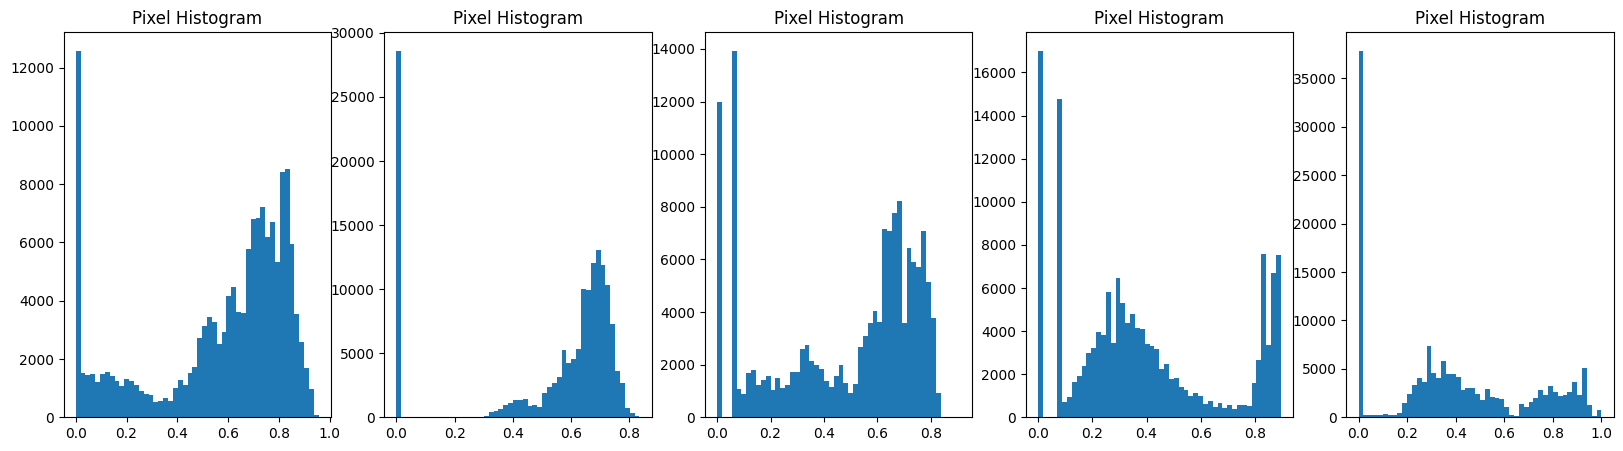

In [16]:
def plot_pixel_distribution(dataset, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(20,5))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    for i in range(num_samples):
        img,_ = dataset[i]
        img = img.permute(1,2,0).numpy()
        img = img * std + mean
        img = np.clip(img, 0, 1)
        axes[i].hist(img.ravel(), bins=50)
        axes[i].set_title("Pixel Histogram")
    plt.show()
plot_pixel_distribution(train_dataset)

# 15. Visualize Augmentations

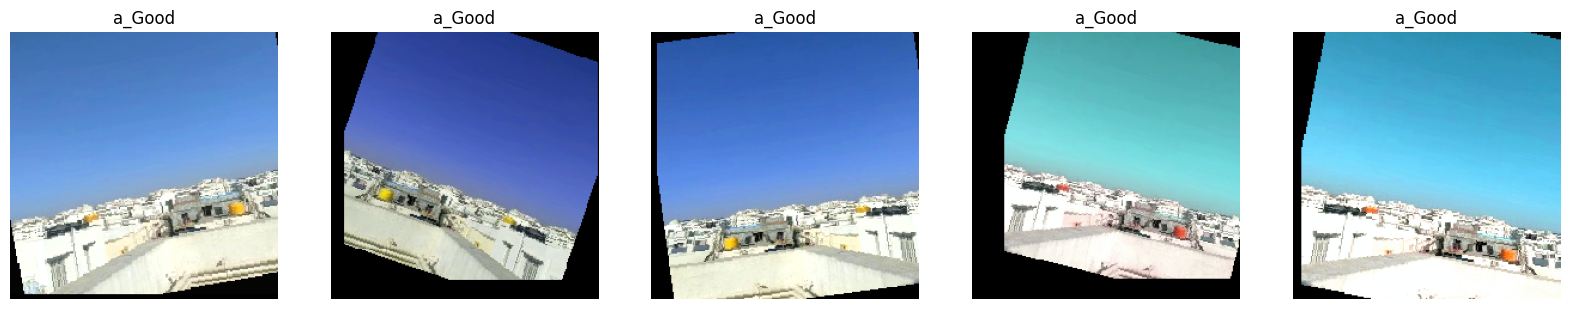

In [17]:
def visualize_augmentations(dataset, num_versions=5):
    idx = np.random.randint(len(dataset))
    img, label = dataset[idx]
    fig, axes = plt.subplots(1, num_versions, figsize=(20,4))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    for i in range(num_versions):
        aug,_ = dataset[idx]
        aug = aug.permute(1,2,0).numpy()
        aug = aug * std + mean
        aug = np.clip(aug,0,1)
        axes[i].imshow(aug)
        axes[i].set_title(inv_class_map[label])
        axes[i].axis("off")
    plt.show()
visualize_augmentations(train_dataset)

# 16. Remove corrupted images

In [18]:
def filter_valid_images(df):
    valid = []
    for p in df["image_path"]:
        try:
            Image.open(p).verify()
            valid.append(True)
        except:
            valid.append(False)
    return df[valid]
train_df = filter_valid_images(train_df)
val_df   = filter_valid_images(val_df)

In [19]:
from collections import Counter
class_counts = Counter(train_df["label"])
num_classes = 6
total_samples = sum(class_counts.values())
class_weights = []
for i in range(num_classes):
    class_weights.append(total_samples / (num_classes * class_counts[i]))
class_weights = torch.tensor(class_weights, dtype=torch.float32)
class_weights

tensor([1.3236, 1.2973, 0.7127, 0.7779, 0.9299, 1.4093])

In [20]:
import torchvision.models as models
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
# Freeze early layers (important)
for param in model.parameters():
    param.requires_grad = False
# Replace classifier head
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 6)
)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


In [21]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.3)

In [22]:
from tqdm import tqdm

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

In [23]:
EPOCHS = 12
train_losses, val_losses = [], []
train_accs, val_accs = [], []
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")


Epoch 1/12


100%|██████████| 306/306 [01:13<00:00,  4.19it/s]


Train Loss: 0.8986 | Train Acc: 0.6438
Val   Loss: 0.5375 | Val   Acc: 0.7888

Epoch 2/12


100%|██████████| 306/306 [01:12<00:00,  4.23it/s]


Train Loss: 0.6580 | Train Acc: 0.7338
Val   Loss: 0.5014 | Val   Acc: 0.8113

Epoch 3/12


...

Train Loss: 0.4168 | Train Acc: 0.8369
Val   Loss: 0.2785 | Val   Acc: 0.8897

Epoch 11/12


100%|██████████| 306/306 [01:12<00:00,  4.21it/s]


Train Loss: 0.4274 | Train Acc: 0.8258
Val   Loss: 0.2562 | Val   Acc: 0.8979

Epoch 12/12


100%|██████████| 306/306 [01:14<00:00,  4.13it/s]


Train Loss: 0.3978 | Train Acc: 0.8431
Val   Loss: 0.2593 | Val   Acc: 0.8987


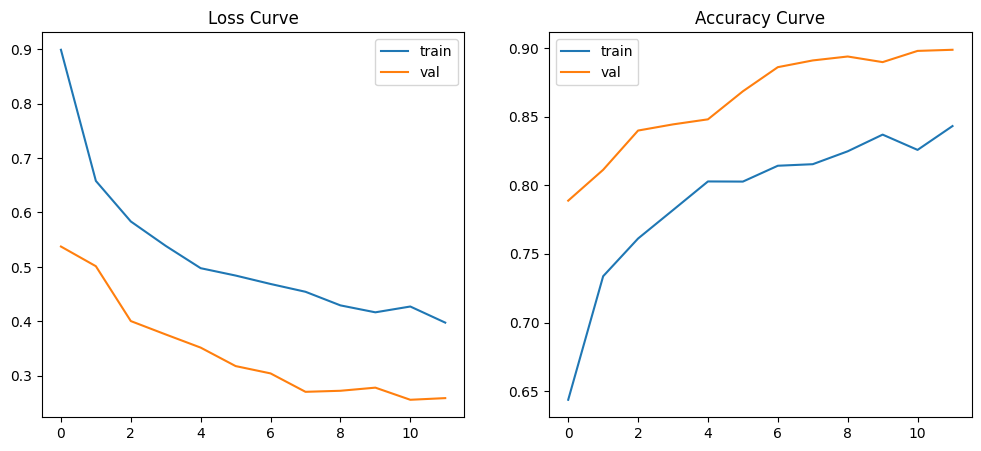

In [24]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses,label="train")
plt.plot(val_losses,label="val")
plt.title("Loss Curve")
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_accs,label="train")
plt.plot(val_accs,label="val")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

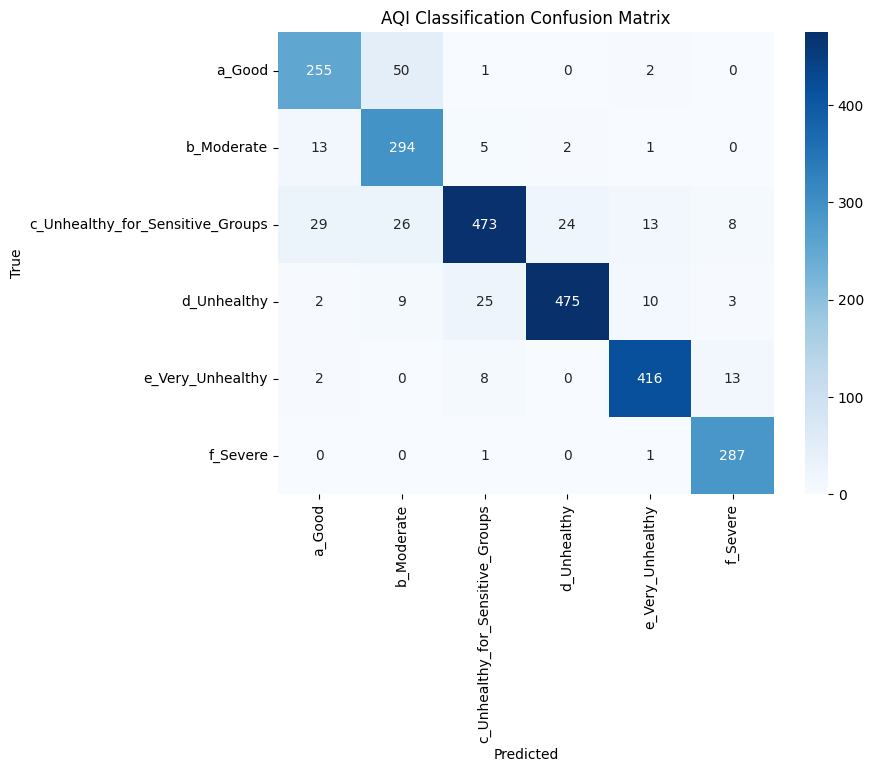

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       308
           1       0.78      0.93      0.85       315
           2       0.92      0.83      0.87       573
           3       0.95      0.91      0.93       524
           4       0.94      0.95      0.94       439
           5       0.92      0.99      0.96       289

    accuracy                           0.90      2448
   macro avg       0.89      0.91      0.90      2448
weighted avg       0.90      0.90      0.90      2448



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_map.keys(),
            yticklabels=class_map.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("AQI Classification Confusion Matrix")
plt.show()
print(classification_report(all_labels, all_preds))

In [26]:
torch.save(model.state_dict(), "aqi_resnet50.pth")

In [28]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.3/159.3 kB 15.9 MB/s eta 0:00:00


In [29]:
dummy_input = torch.randn(1, 3, 224, 224).to(device)
torch.onnx.export(
    model,
    dummy_input,
    "aqi_cnn.onnx",
    input_names=["image"],
    output_names=["aqi_class"],
    opset_version=11,
    dynamic_axes={"image": {0: "batch_size"},
                  "aqi_class": {0: "batch_size"}}
)
print("ONNX model exported successfully")

/tmp/ipython-input-3551916745.py:2: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0215 14:53:07.870000 5660 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0215 14:53:11.101000 5660 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, ali

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Translate the graph into ONNX... ✅
Applied 108 of general pattern rewrite rules.
ONNX model exported successfully
